In [ ]:
from google.colab import drive
drive.mount("/content/gdrive")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

import warnings

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:
# read in the preprocessed dataframe
df = pd.read_csv("/content/gdrive/MyDrive/NaturalLanguageProcessing/apple_text_preprocessed.csv", usecols=["corpus", "overall"])
df.head(5)

,overall,corpus
0,1.0,Dont buy these The only good thing about these...
1,2.0,I suppose... These headphones came pretty quic...
2,5.0,Awesome! I was replacing my earbuds and was re...
3,4.0,iPod headphones They are pretty good. I would ...
4,1.0,Fits Like a Glove... on OJ Simpson's Hand Thes...


# 1 Word preprocessing
- Lowercase, remove stopwords, lemmatize, remove non-alphanumeric characters

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Convert text to lowercase
df["corpus"] = df["corpus"].str.lower()

# Removes stopwords, lemmatizes words, and removes words/chars that are non-alphanumeric
df["corpus"] = df["corpus"].apply(lambda x: " ".join([lemmatizer.lemmatize(word) for word in word_tokenize(x) if word not in stop_words and word.isalnum()]))

df.head(3)

,overall,corpus
0,1.0,dont buy good thing headphone delivery time ca...
1,2.0,suppose headphone came pretty quick say great ...
2,5.0,awesome replacing earbuds really hesitant spen...


# 2 Train-Test split

In [ ]:
xTrain, xTest, yTrain, yTest = train_test_split(df["corpus"], df["overall"], test_size=0.2)

# 3 Classification function

In [ ]:
# Run Randomized Grid Search Cross-Validation on either Logistic Regression or Naive Bayes
# With a specific parameter grid for each (5 folds, 50 different combinations -> 250 fits)
def run_classification(classifier, X, y):
    # Pipeline
    pipe = Pipeline([
        ("vect", CountVectorizer(decode_error='ignore')),
        ("tfidf", TfidfTransformer()),
        ("clf", classifier)
    ])

    # Define the parameters for the random search based on the classifier
    if type(classifier) == LogisticRegression:
        parameters = {
            "vect__max_features": [50, 100, 150, 200, 250, 300, 350, 400, 450, 500], # max features in the input vectors
            "clf__solver": ['lbfgs', 'newton-cg', 'newton-cholesky', 'sag'], # solver for the optimization problem
            "clf__C": [0.01, 0.1, 1, 10, 100], # regularization parameter
            "clf__penalty": [None, 'l2'], # norm used in the penalization
            "clf__max_iter": [10000], # tolerance for stopping criteria
            "clf__class_weight": ["balanced"]
            }
    elif type(classifier) == MultinomialNB:
        parameters = {
            "vect__max_features": [50, 100, 150, 200, 250, 300, 350, 400, 450, 500], # max features in the input vectors
            "clf__alpha": [0.01, 0.1, 1, 10, 100], # laplace smoothing
            "clf__fit_prior": [True, False] # whether to learn class prior probabilities or not
            }
    else:
        raise ValueError("Classifier not supported")

    warnings.filterwarnings("ignore", category=UserWarning)
    # Random search
    rnd_search = RandomizedSearchCV(pipe, parameters, cv=5, verbose=2, n_jobs=-1, n_iter=50)
    rnd_search.fit(X, y)

    # Pring best combination of parameters
    print("Best parameter (CV score=%0.3f):" % rnd_search.best_score_)
    print(rnd_search.best_params_)

    return rnd_search.best_estimator_, pipe

In [ ]:
# Logistic Regression
lr_model, pipeline = run_classification(LogisticRegression(), xTrain, yTrain)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameter (CV score=0.649):
{'vect__max_features': 500, 'clf__solver': 'newton-cholesky', 'clf__penalty': 'l2', 'clf__max_iter': 10000, 'clf__class_weight': 'balanced', 'clf__C': 1}


In [ ]:
# Naive Bayes
nb_model, pipeline = run_classification(MultinomialNB(), xTrain, yTrain)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameter (CV score=0.679):
{'vect__max_features': 400, 'clf__fit_prior': True, 'clf__alpha': 1}


# 4 Graphs, predictions, and evaluations

In [ ]:
# Function that runs the prediction on the test set and creates the evaluation metrics
# Classification Report, Confusion Matrix, ROC, and Precision-Recall
def plot_roc_and_pr_curves(model, X_test, y_test):
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Classification Report
    print(classification_report(y_test, y_pred))
    
    # Confustion Matrx
    ax= plt.subplot()
    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
    sns.heatmap(cm, annot=True, fmt='g', ax=ax, cmap="Blues")
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix')
    ax.xaxis.set_ticklabels(['1', '2', '3', '4', '5'])
    ax.yaxis.set_ticklabels(['1', '2', '3', '4', '5'])

    # Compute class probabilities
    y_prob = model.predict_proba(X_test)

    # Compute ROC curve and ROC area for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(len(np.unique(y_test))):
        fpr[i], tpr[i], _ = roc_curve((y_test == i+1).astype(int), y_prob[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Compute Precision-Recall curve and average precision for each class
    precision = dict()
    recall = dict()
    pr_auc = dict()
    for i in range(len(np.unique(y_test))):
        precision[i], recall[i], _ = precision_recall_curve((y_test == i+1).astype(int), y_prob[:, i])
        pr_auc[i] = average_precision_score((y_test == i+1).astype(int), y_prob[:, i])

    # Plot ROC curves for each class
    plt.figure()
    colors = ['blue', 'red', 'green', 'orange', 'purple']  # Customize colors if needed
    for i, color in zip(range(len(np.unique(y_test))), colors):
        plt.plot(fpr[i], tpr[i], color=color, label='ROC curve class %d (AUC = %0.2f)' % (i+1, roc_auc[i]))
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc='lower right')

    # Plot Precision-Recall curves for each class
    plt.figure()
    for i, color in zip(range(len(np.unique(y_test))), colors):
        plt.plot(recall[i], precision[i], color=color, label='PR curve class %d (AP = %0.2f)' % (i+1, pr_auc[i]))
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend(loc='lower right')

    # Show the plots
    plt.show()

              precision    recall  f1-score   support

         1.0       0.73      0.76      0.74      2701
         2.0       0.20      0.23      0.21       666
         3.0       0.23      0.31      0.26       714
         4.0       0.32      0.32      0.32      1164
         5.0       0.86      0.78      0.82      4918

    accuracy                           0.65     10163
   macro avg       0.47      0.48      0.47     10163
weighted avg       0.68      0.65      0.66     10163



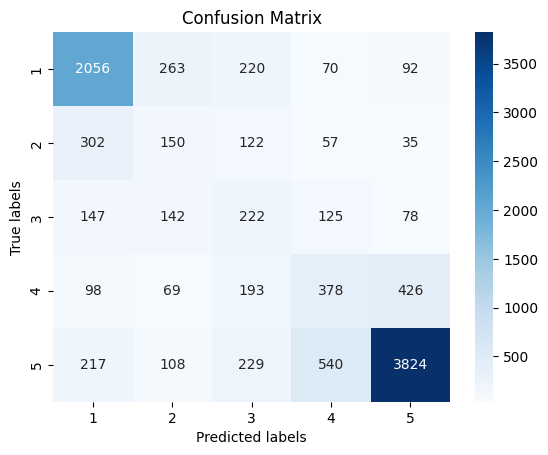

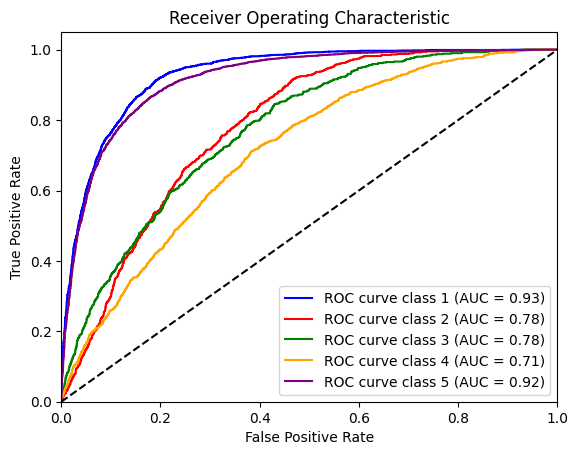

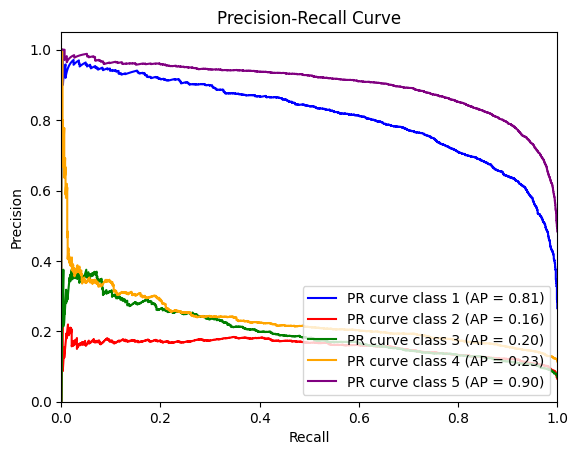

In [ ]:
# Logistic Regression
plot_roc_and_pr_curves(lr_model, xTest, yTest)

              precision    recall  f1-score   support

         1.0       0.67      0.81      0.73      2701
         2.0       0.25      0.00      0.00       666
         3.0       0.50      0.03      0.06       714
         4.0       0.46      0.03      0.06      1164
         5.0       0.69      0.95      0.80      4918

    accuracy                           0.68     10163
   macro avg       0.51      0.37      0.33     10163
weighted avg       0.62      0.68      0.59     10163



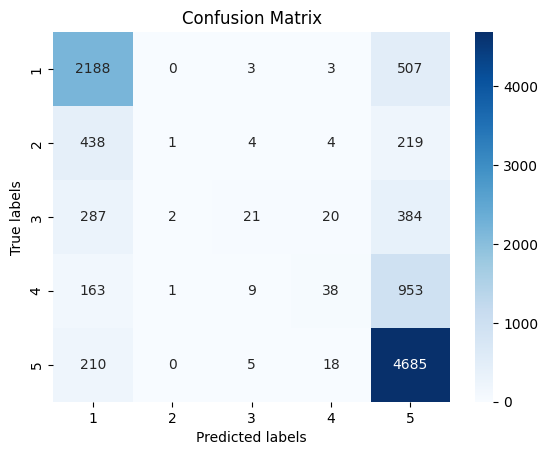

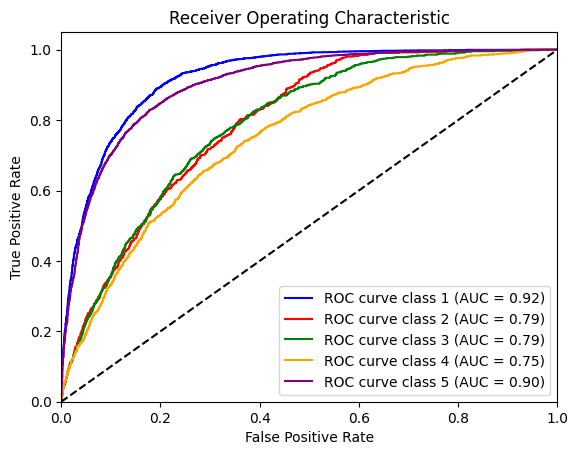

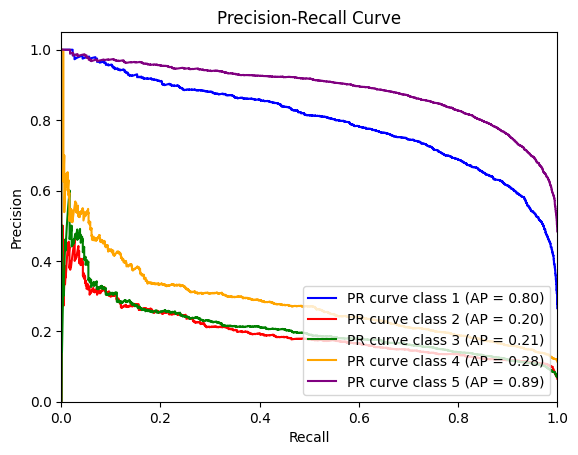

In [ ]:
# Naive Bayes
plot_roc_and_pr_curves(nb_model, xTest, yTest)